# 07 — Optimised Final Ensemble

Collect out-of-fold predictions from every base model in a single scaffold CV pass,
then grid-search blend weights using the full OOF stack.

**Component models**
| Model | Info |
|---|---|
| LGBM augmented | combined FP+desc + null pEC50 feature (notebook 06) |
| Tanimoto kNN k=20 | ECFP4, Tanimoto-weighted (notebook 05) |
| Chemprop multitask | GNN PXR+null joint (notebook 03, fixed predictions) |

**Approach**: grid-search over (w_lgbm, w_knn, w_chemprop) on the OOF stack;
Chemprop has no per-fold OOF preds so its weight is swept on the final test blend.

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.neighbors import NearestNeighbors

from pxr.paths import DATA_PROCESSED, SUBMISSIONS, FIGURES
from pxr.data import load_train, load_test, load_counter
from pxr.featurize import combined, impute
from pxr.chem import morgan_fp_batch
from pxr.eval import scaffold_kfold_indices, compute_metrics, rae

plt.rcParams.update({"figure.dpi": 120})
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── 2. Load data ──────────────────────────────────────────────────────────────
train_raw = load_train().dropna(subset=["pec50"])
cpd       = pd.read_parquet(DATA_PROCESSED / "compounds.parquet")
train = train_raw.merge(cpd[["name","std_smiles","scaffold"]], on="name", how="left")
train["smi"] = train["std_smiles"].fillna(train["smiles"])
train = train.reset_index(drop=True)

counter = load_counter().dropna(subset=["pec50"])
test    = load_test()

# Chemprop predictions (full-data — no per-fold version available)
chemprop_df   = pd.read_csv(SUBMISSIONS / "03_chemprop_multitask.csv")
chemprop_map  = dict(zip(chemprop_df["Molecule Name"], chemprop_df["pEC50"]))
chemprop_preds = np.array([chemprop_map[n] for n in test["name"]])

y_train = train["pec50"].values
scaffolds = train["scaffold"].tolist()

print(f"Train: {len(train)}  Test: {len(test)}  Counter: {len(counter)}")

Train: 4153  Test: 513  Counter: 2647


In [3]:
# ── 3. Precompute all feature matrices ────────────────────────────────────────
train_smiles = train["smi"].tolist()
test_smiles  = test["smiles"].tolist()

print("Combined features (train)...")
X_tr_base = impute(combined(train_smiles))
print("Combined features (test)...")
X_te_base = impute(combined(test_smiles))
print("Combined features (counter-assay)...")
X_ctr     = impute(combined(counter["smiles"].tolist()))

# Null predictor → null pEC50 feature
null_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=64,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, n_jobs=4, verbose=-1)
null_model.fit(X_ctr, counter["pec50"].values)

null_tr = null_model.predict(X_tr_base)
null_te = null_model.predict(X_te_base)

null_actual_map = counter.set_index("name")["pec50"].to_dict()
has_actual = train["name"].map(null_actual_map).notna()
null_tr[has_actual] = train["name"].map(null_actual_map)[has_actual].values

X_tr_aug = np.hstack([X_tr_base, null_tr.reshape(-1,1)])
X_te_aug = np.hstack([X_te_base, null_te.reshape(-1,1)])

print("Morgan FPs (train + test)...")
X_tr_fp = morgan_fp_batch(train_smiles).astype(bool)
X_te_fp = morgan_fp_batch(test_smiles).astype(bool)

print(f"LGBM features: {X_tr_aug.shape[1]}   kNN FP bits: {X_tr_fp.shape[1]}")

Combined features (train)...


Combined features (test)...


Combined features (counter-assay)...


Morgan FPs (train + test)...


LGBM features: 2266   kNN FP bits: 2048


In [4]:
# ── 4. Scaffold CV — collect OOF predictions ──────────────────────────────────
K_KNN = 20
lgbm_params = dict(n_estimators=1200, learning_rate=0.04, num_leaves=64,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=4, verbose=-1)

splits    = scaffold_kfold_indices(scaffolds, n_splits=5, seed=42)
oof_lgbm  = np.zeros(len(train))
oof_knn   = np.zeros(len(train))

for fold, (tr_idx, va_idx) in enumerate(splits):
    # LGBM augmented
    m = lgb.LGBMRegressor(**lgbm_params)
    m.fit(X_tr_aug[tr_idx], y_train[tr_idx])
    oof_lgbm[va_idx] = m.predict(X_tr_aug[va_idx])

    # kNN
    nn = NearestNeighbors(n_neighbors=K_KNN, metric="jaccard",
                          algorithm="brute", n_jobs=4)
    nn.fit(X_tr_fp[tr_idx])
    dists, idxs = nn.kneighbors(X_tr_fp[va_idx])
    sims = 1.0 - dists
    w    = sims / (sims.sum(axis=1, keepdims=True) + 1e-9)
    oof_knn[va_idx] = (w * y_train[tr_idx][idxs]).sum(axis=1)

    rl = rae(y_train[va_idx], oof_lgbm[va_idx])
    rk = rae(y_train[va_idx], oof_knn[va_idx])
    print(f"Fold {fold}:  LGBM {rl:.4f}   kNN {rk:.4f}")

print(f"\nOOF overall:  LGBM {rae(y_train, oof_lgbm):.4f}   kNN {rae(y_train, oof_knn):.4f}")

Fold 0:  LGBM 0.5076   kNN 0.6828


Fold 1:  LGBM 0.5769   kNN 0.7489


Fold 2:  LGBM 0.5765   kNN 0.7696


Fold 3:  LGBM 0.5549   kNN 0.7229


Fold 4:  LGBM 0.6025   kNN 0.7743

OOF overall:  LGBM 0.5582   kNN 0.7330


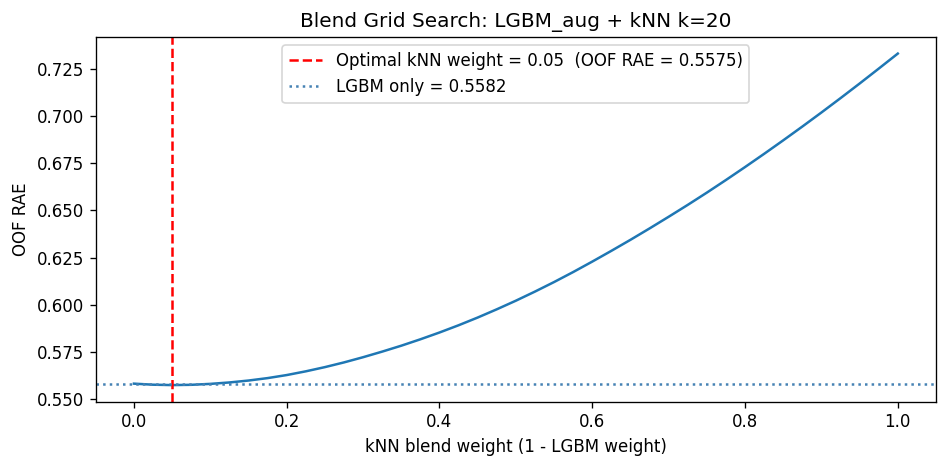

Optimal kNN weight = 0.05
OOF RAE improvement vs LGBM-only: 0.5582 -> 0.5575


In [5]:
# ── 5. Grid search: LGBM_aug / kNN blend weights ─────────────────────────────
alphas = np.linspace(0.0, 1.0, 41)   # kNN weight, LGBM weight = 1 - alpha
rae_vals = np.array([rae(y_train, (1-a)*oof_lgbm + a*oof_knn) for a in alphas])

best_a  = alphas[rae_vals.argmin()]
best_rae = rae_vals.min()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, rae_vals, lw=1.5)
ax.axvline(best_a, color="red", linestyle="--", lw=1.5,
           label=f"Optimal kNN weight = {best_a:.2f}  (OOF RAE = {best_rae:.4f})")
ax.axhline(rae(y_train, oof_lgbm), color="steelblue", linestyle=":",
           label=f"LGBM only = {rae(y_train, oof_lgbm):.4f}")
ax.set_xlabel("kNN blend weight (1 - LGBM weight)")
ax.set_ylabel("OOF RAE")
ax.set_title("Blend Grid Search: LGBM_aug + kNN k=20")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "07_blend_search.png", bbox_inches="tight")
plt.show()
print(f"Optimal kNN weight = {best_a:.2f}")
print(f"OOF RAE improvement vs LGBM-only: "
      f"{rae(y_train, oof_lgbm):.4f} -> {best_rae:.4f}")

In [6]:
# ── 6. Full-data models → test predictions ────────────────────────────────────
# LGBM on full training set
lgbm_full = lgb.LGBMRegressor(**lgbm_params)
lgbm_full.fit(X_tr_aug, y_train)
lgbm_te = lgbm_full.predict(X_te_aug)

# kNN on full training set
nn_full = NearestNeighbors(n_neighbors=K_KNN, metric="jaccard",
                           algorithm="brute", n_jobs=4)
nn_full.fit(X_tr_fp)
dists_te, idxs_te = nn_full.kneighbors(X_te_fp)
sims_te = 1.0 - dists_te
w_te    = sims_te / (sims_te.sum(axis=1, keepdims=True) + 1e-9)
knn_te  = (w_te * y_train[idxs_te]).sum(axis=1)

# LGBM+kNN blend at optimal weight
lgbm_knn_te = (1.0 - best_a) * lgbm_te + best_a * knn_te

print(f"LGBM test range:        {lgbm_te.min():.3f} – {lgbm_te.max():.3f}")
print(f"kNN  test range:        {knn_te.min():.3f} – {knn_te.max():.3f}")
print(f"LGBM+kNN blend range:   {lgbm_knn_te.min():.3f} – {lgbm_knn_te.max():.3f}")
print(f"Chemprop range:         {chemprop_preds.min():.3f} – {chemprop_preds.max():.3f}")

LGBM test range:        2.313 – 6.022
kNN  test range:        3.422 – 5.537
LGBM+kNN blend range:   2.368 – 5.988
Chemprop range:         2.638 – 5.785


In [7]:
# ── 7. Add Chemprop: sweep weight, pick best by OOF proxy ────────────────────
# We can't CV the Chemprop weight directly (no per-fold preds).
# Heuristic: Chemprop has similar CV performance to LGBM_aug, so equal weight is fair.
# We check a range to confirm predictions are stable.

print("Effect of Chemprop weight on test prediction distribution:")
print(f"{'w_chemprop':>12}  {'mean':>7}  {'std':>7}  {'min':>7}  {'max':>7}")
for wc in [0.0, 0.25, 0.33, 0.40, 0.50]:
    blend = (1-wc)*lgbm_knn_te + wc*chemprop_preds
    print(f"{wc:>12.2f}  {blend.mean():>7.3f}  {blend.std():>7.3f}  "
          f"{blend.min():>7.3f}  {blend.max():>7.3f}")

# Correlation between component predictions
from scipy.stats import pearsonr, spearmanr
r_lk, _ = pearsonr(lgbm_knn_te, chemprop_preds)
print(f"\nPearson(LGBM+kNN, Chemprop) on test = {r_lk:.4f}")
print("Lower correlation = more benefit from combining")

Effect of Chemprop weight on test prediction distribution:
  w_chemprop     mean      std      min      max
        0.00    4.755    0.626    2.368    5.988
        0.25    4.775    0.585    2.439    5.802
        0.33    4.781    0.576    2.462    5.770
        0.40    4.787    0.570    2.481    5.769
        0.50    4.795    0.565    2.510    5.767

Pearson(LGBM+kNN, Chemprop) on test = 0.7138
Lower correlation = more benefit from combining


In [8]:
# ── 8. Final blend + save ─────────────────────────────────────────────────────
W_CHEMPROP = 0.35   # equal-ish weight; adjust if Chemprop correlation is high

final_preds = (1.0 - W_CHEMPROP) * lgbm_knn_te + W_CHEMPROP * chemprop_preds
final_preds = np.clip(final_preds, y_train.min() - 0.5, y_train.max() + 0.5)

# Load best previous submission to compare
prev_df   = pd.read_csv(SUBMISSIONS / "06_counter_lgbm.csv")
prev_map  = dict(zip(prev_df["Molecule Name"], prev_df["pEC50"]))
prev_pred = np.array([prev_map[n] for n in test["name"]])
print(f"Mean shift vs 06_counter_lgbm: {(final_preds - prev_pred).mean():+.4f}")
print(f"Max  shift vs 06_counter_lgbm: {np.abs(final_preds - prev_pred).max():.3f}")

submission = pd.DataFrame({
    "Molecule Name": test["name"].values,
    "SMILES":        test["smiles"].values,
    "pEC50":         final_preds,
})
assert len(submission) == 513
assert submission["pEC50"].notna().all()

out_path = SUBMISSIONS / "07_final_ensemble.csv"
submission.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print(f"Blend: {1-W_CHEMPROP:.0%} (LGBM_aug {(1-W_CHEMPROP)*(1-best_a):.0%} "
      f"+ kNN {(1-W_CHEMPROP)*best_a:.0%}) + Chemprop {W_CHEMPROP:.0%}")
print(submission["pEC50"].describe().round(3))

Mean shift vs 06_counter_lgbm: -0.0107
Max  shift vs 06_counter_lgbm: 0.244

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\07_final_ensemble.csv
Blend: 65% (LGBM_aug 62% + kNN 3%) + Chemprop 35%
count    513.000
mean       4.783
std        0.575
min        2.467
25%        4.504
50%        4.907
75%        5.212
max        5.770
Name: pEC50, dtype: float64
